## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [9]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")

# Drop total_litres_of_pure_alcohol column
df = df.drop('total_litres_of_pure_alcohol', axis=1)  

# Convert to tidy format
tidy_df = df.melt(id_vars="country", var_name="drink", value_name="servings")

print(tidy_df.head())

       country          drink  servings
0  Afghanistan  beer_servings         0
1      Albania  beer_servings        89
2      Algeria  beer_servings        25
3      Andorra  beer_servings       245
4       Angola  beer_servings       217


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

     country   drink  servings
117  Namibia    beer       376
261  Grenada  spirit       438
447   France    wine       370


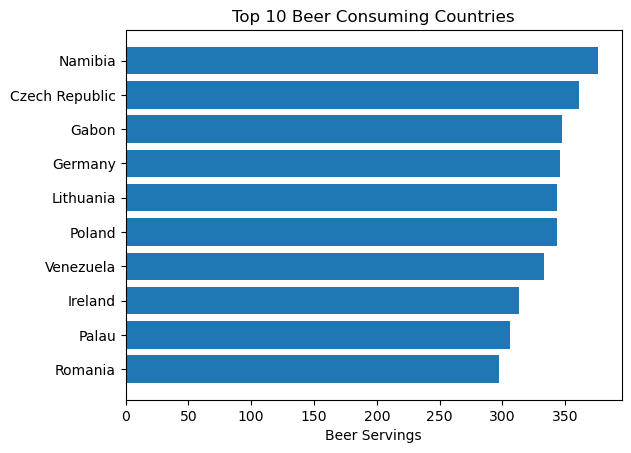

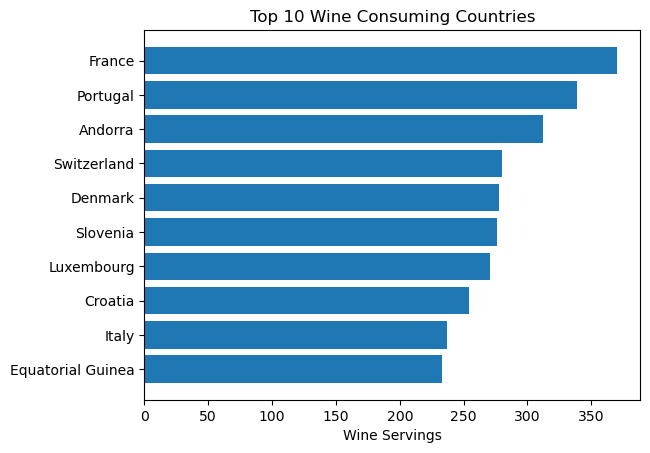

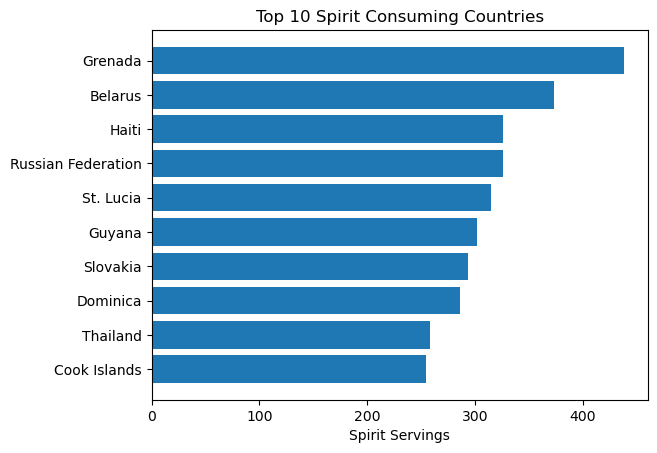

In [14]:
import matplotlib.pyplot as plt

tidy_df["drink"] = tidy_df["drink"].str.replace("_servings", "", regex=False)
tidy_df.head()

top_countries = (
    tidy_df.loc[tidy_df.groupby("drink")["servings"].idxmax()]
    .sort_values("drink")
)

print(top_countries)


top10_beer = (
    tidy_df[tidy_df["drink"] == "beer"]
    .sort_values("servings", ascending=False)
    .head(10)
)

top10_wine = (
    tidy_df[tidy_df["drink"] == "wine"]
    .sort_values("servings", ascending=False)
    .head(10)
)

top10_spirit = (
    tidy_df[tidy_df["drink"] == "spirit"]
    .sort_values("servings", ascending=False)
    .head(10)
)  # Added missing closing parenthesis here

plt.figure()
plt.barh(top10_beer["country"], top10_beer["servings"])
plt.xlabel("Beer Servings")
plt.title("Top 10 Beer Consuming Countries")
plt.gca().invert_yaxis()
plt.show()

plt.figure()
plt.barh(top10_wine["country"], top10_wine["servings"])
plt.xlabel("Wine Servings")
plt.title("Top 10 Wine Consuming Countries")
plt.gca().invert_yaxis()
plt.show()

plt.figure()
plt.barh(top10_spirit["country"], top10_spirit["servings"])
plt.xlabel("Spirit Servings")
plt.title("Top 10 Spirit Consuming Countries")
plt.gca().invert_yaxis()
plt.show()

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [15]:
wide_df.columns.name = None
wide_df = tidy_df.pivot_table(
    index="country",
    columns="drink",
    values="servings"
).reset_index()

print(wide_df.head())

drink      country   beer  spirit   wine
0      Afghanistan    0.0     0.0    0.0
1          Albania   89.0   132.0   54.0
2          Algeria   25.0     0.0   14.0
3          Andorra  245.0   138.0  312.0
4           Angola  217.0    57.0   45.0
